In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
df = pd.read_csv('raw_data.csv')
df

,id,name,age,country,gender
0,1,John Doe,29.0,USA,Male
1,1,John Doe,29.0,USA,Male
2,2,Jane Smith,NaN,Canada,Female
3,3,Alex,NaN,USA,Unknown
4,4,Maria Garcia,34.0,Spain,Female
5,5,Li Wei,27.0,China,Male
6,6,NaN,45.0,India,Female
7,7,Ahmed Khan,38.0,NaN,Male
8,8,Sara Ali,31.0,UAE,Female
9,9,Noah Brown,NaN,UK,Male


In [4]:
df.isnull()

,id,name,age,country,gender
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,True,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,True,False,False,False
7,False,False,False,True,False
8,False,False,False,False,False
9,False,False,True,False,False


In [5]:
df.dropna() # drops all the rows with null values
#df.dropna(inplace=True) # drops all the rows with null values and updates the dataframe
df.dropna(axis=1) # drops all the columns with null values

,id,gender
0,1,Male
1,1,Male
2,2,Female
3,3,Unknown
4,4,Female
5,5,Male
6,6,Female
7,7,Male
8,8,Female
9,9,Male


In [6]:
df["age"].fillna(df["age"].mean()) # fills the null values in the age column with the mean of the age column

0     29.000
1     29.000
2     32.375
3     32.375
4     34.000
5     27.000
6     45.000
7     38.000
8     31.000
9     32.375
10    26.000
Name: age, dtype: float64

In [7]:
cleaned_data = df.copy() # creates a copy of the dataframe
age_mean = cleaned_data["age"].mean() # calculates the mean of the age column
cleaned_data["age"] = cleaned_data["age"].fillna(age_mean) # fills the null values in the age column with the mean of the age column and updates the dataframe
cleaned_data

,id,name,age,country,gender
0,1,John Doe,29.000,USA,Male
1,1,John Doe,29.000,USA,Male
2,2,Jane Smith,32.375,Canada,Female
3,3,Alex,32.375,USA,Unknown
4,4,Maria Garcia,34.000,Spain,Female
5,5,Li Wei,27.000,China,Male
6,6,NaN,45.000,India,Female
7,7,Ahmed Khan,38.000,NaN,Male
8,8,Sara Ali,31.000,UAE,Female
9,9,Noah Brown,32.375,UK,Male


In [8]:
#handle duplicates
df[["country", "gender"]].duplicated() # returns a boolean series indicating whether each value in the country column is a duplicate or not
df2 = df.copy()
df2.drop_duplicates(inplace=True) # drops all the duplicate rows and updates the dataframe

In [9]:
#add income column
df2["income"] = [60000, 40000, 50000, 70000, 30000, 80000, 90000, 20000, 10000, 110000] 


In [10]:
#feature engineering
df2["tax"] = df2["income"].apply(lambda x: "20%" if x > 50000 else "10%") # creates a new column called tax and fills it with 20% if the income is greater than 50000 and 10% otherwise
df2

,id,name,age,country,gender,income,tax
0,1,John Doe,29.0,USA,Male,60000,20%
2,2,Jane Smith,NaN,Canada,Female,40000,10%
3,3,Alex,NaN,USA,Unknown,50000,10%
4,4,Maria Garcia,34.0,Spain,Female,70000,20%
5,5,Li Wei,27.0,China,Male,30000,10%
6,6,NaN,45.0,India,Female,80000,20%
7,7,Ahmed Khan,38.0,NaN,Male,90000,20%
8,8,Sara Ali,31.0,UAE,Female,20000,10%
9,9,Noah Brown,NaN,UK,Male,10000,10%
10,10,Emma Wilson,26.0,Australia,Female,110000,20%


In [11]:
gender_map = { "Male": "M", "Female": "F", "Unknown": "U" }
df2["gender"] = df2["gender"].map(gender_map) # maps the values in the gender column
df2

,id,name,age,country,gender,income,tax
0,1,John Doe,29.0,USA,M,60000,20%
2,2,Jane Smith,NaN,Canada,F,40000,10%
3,3,Alex,NaN,USA,U,50000,10%
4,4,Maria Garcia,34.0,Spain,F,70000,20%
5,5,Li Wei,27.0,China,M,30000,10%
6,6,NaN,45.0,India,F,80000,20%
7,7,Ahmed Khan,38.0,NaN,M,90000,20%
8,8,Sara Ali,31.0,UAE,F,20000,10%
9,9,Noah Brown,NaN,UK,M,10000,10%
10,10,Emma Wilson,26.0,Australia,F,110000,20%


In [12]:
df2.assign(age_group = df2["age"].apply(lambda x: "Young" if x < 30 else "Old")) # creates a new column called age_group and fills it with Young if the age is less than 30 and Old otherwise   

,id,name,age,country,gender,income,tax,age_group
0,1,John Doe,29.0,USA,M,60000,20%,Young
2,2,Jane Smith,NaN,Canada,F,40000,10%,Old
3,3,Alex,NaN,USA,U,50000,10%,Old
4,4,Maria Garcia,34.0,Spain,F,70000,20%,Old
5,5,Li Wei,27.0,China,M,30000,10%,Young
6,6,NaN,45.0,India,F,80000,20%,Old
7,7,Ahmed Khan,38.0,NaN,M,90000,20%,Old
8,8,Sara Ali,31.0,UAE,F,20000,10%,Old
9,9,Noah Brown,NaN,UK,M,10000,10%,Old
10,10,Emma Wilson,26.0,Australia,F,110000,20%,Young


In [13]:
df2.assign(new_income = df2["income"] * 1.1) # creates a new column called new_income and fills it with the income column multiplied by 1.1

,id,name,age,country,gender,income,tax,new_income
0,1,John Doe,29.0,USA,M,60000,20%,66000.0
2,2,Jane Smith,NaN,Canada,F,40000,10%,44000.0
3,3,Alex,NaN,USA,U,50000,10%,55000.0
4,4,Maria Garcia,34.0,Spain,F,70000,20%,77000.0
5,5,Li Wei,27.0,China,M,30000,10%,33000.0
6,6,NaN,45.0,India,F,80000,20%,88000.0
7,7,Ahmed Khan,38.0,NaN,M,90000,20%,99000.0
8,8,Sara Ali,31.0,UAE,F,20000,10%,22000.0
9,9,Noah Brown,NaN,UK,M,10000,10%,11000.0
10,10,Emma Wilson,26.0,Australia,F,110000,20%,121000.0


In [14]:
df2.columns = ["Id", "Name", "Age", "Country", "Gender", "Income", "Tax"]
df2

,Id,Name,Age,Country,Gender,Income,Tax
0,1,John Doe,29.0,USA,M,60000,20%
2,2,Jane Smith,NaN,Canada,F,40000,10%
3,3,Alex,NaN,USA,U,50000,10%
4,4,Maria Garcia,34.0,Spain,F,70000,20%
5,5,Li Wei,27.0,China,M,30000,10%
6,6,NaN,45.0,India,F,80000,20%
7,7,Ahmed Khan,38.0,NaN,M,90000,20%
8,8,Sara Ali,31.0,UAE,F,20000,10%
9,9,Noah Brown,NaN,UK,M,10000,10%
10,10,Emma Wilson,26.0,Australia,F,110000,20%


In [15]:
df2.rename(columns={"Id":"ID"})

,ID,Name,Age,Country,Gender,Income,Tax
0,1,John Doe,29.0,USA,M,60000,20%
2,2,Jane Smith,NaN,Canada,F,40000,10%
3,3,Alex,NaN,USA,U,50000,10%
4,4,Maria Garcia,34.0,Spain,F,70000,20%
5,5,Li Wei,27.0,China,M,30000,10%
6,6,NaN,45.0,India,F,80000,20%
7,7,Ahmed Khan,38.0,NaN,M,90000,20%
8,8,Sara Ali,31.0,UAE,F,20000,10%
9,9,Noah Brown,NaN,UK,M,10000,10%
10,10,Emma Wilson,26.0,Australia,F,110000,20%


In [16]:
df

,id,name,age,country,gender
0,1,John Doe,29.0,USA,Male
1,1,John Doe,29.0,USA,Male
2,2,Jane Smith,NaN,Canada,Female
3,3,Alex,NaN,USA,Unknown
4,4,Maria Garcia,34.0,Spain,Female
5,5,Li Wei,27.0,China,Male
6,6,NaN,45.0,India,Female
7,7,Ahmed Khan,38.0,NaN,Male
8,8,Sara Ali,31.0,UAE,Female
9,9,Noah Brown,NaN,UK,Male


In [17]:
df3 = df.copy()
df3[["name","age","country","gender","id"]] #shift id column to end

,name,age,country,gender,id
0,John Doe,29.0,USA,Male,1
1,John Doe,29.0,USA,Male,1
2,Jane Smith,NaN,Canada,Female,2
3,Alex,NaN,USA,Unknown,3
4,Maria Garcia,34.0,Spain,Female,4
5,Li Wei,27.0,China,Male,5
6,NaN,45.0,India,Female,6
7,Ahmed Khan,38.0,NaN,Male,7
8,Sara Ali,31.0,UAE,Female,8
9,Noah Brown,NaN,UK,Male,9


In [18]:
#2nd method
new_col_order = [col for col in df3.columns if col != "id"] + ["id"]
df3[new_col_order]

,name,age,country,gender,id
0,John Doe,29.0,USA,Male,1
1,John Doe,29.0,USA,Male,1
2,Jane Smith,NaN,Canada,Female,2
3,Alex,NaN,USA,Unknown,3
4,Maria Garcia,34.0,Spain,Female,4
5,Li Wei,27.0,China,Male,5
6,NaN,45.0,India,Female,6
7,Ahmed Khan,38.0,NaN,Male,7
8,Sara Ali,31.0,UAE,Female,8
9,Noah Brown,NaN,UK,Male,9


In [31]:
df.groupby("country")["age"].mean() # groups the dataframe by country and calculates the mean of the age column for each group
df2.groupby("Country")["Income"].agg(["mean", "min", "max"]) # groups the dataframe by country and calculates the mean, min and max of the income column for each group
df2.groupby("Country")["Income"].agg(avg_salary = "mean", min_salary = "min", max_salary = "max") # groups the dataframe by country and calculates the mean, min and max of the income column for each group and renames the columns
df2.groupby("Country").agg({
    "Income": "max",
    "Tax": lambda x: (x == "20%").sum() # counts the number of rows in the tax column that have the value 20% for each country
})

,Income,Tax
Country,,
Australia,110000,1
Canada,40000,0
China,30000,0
India,80000,1
Spain,70000,1
UAE,20000,0
UK,10000,0
USA,60000,1


In [34]:
#melt and pivot
df = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "country": ["USA", "UK", "Canada"]
})
df_melted = df.melt(id_vars=["id", "name"], value_vars=["age", "country"], var_name="variable", value_name="value") # melts the dataframe and creates a new dataframe with the id and name columns as id_vars and the age and country columns as value_vars
df_melted

,id,name,variable,value
0,1,Alice,age,25
1,2,Bob,age,30
2,3,Charlie,age,35
3,1,Alice,country,USA
4,2,Bob,country,UK
5,3,Charlie,country,Canada


In [36]:
#pivot
df_pivoted = df_melted.pivot(index=["id", "name"], columns="variable", values="value").reset_index() # pivots the melted dataframe and creates a new
# dataframe with the id and name columns as index and the variable column as columns and the value column as values
df_pivoted

variable,id,name,age,country
0,1,Alice,25,USA
1,2,Bob,30,UK
2,3,Charlie,35,Canada


In [35]:
df

,id,name,age,country
0,1,Alice,25,USA
1,2,Bob,30,UK
2,3,Charlie,35,Canada


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 491.1 kB/s  0:00:19m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 629.3 kB/s  0:00:07 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 1.2 MB/s  0:00:05 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


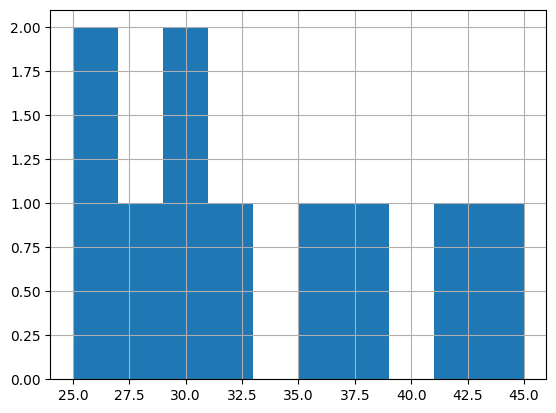

In [40]:
%pip install matplotlib
import matplotlib.pyplot as plt

df["Age"].hist() # creates a histogram of the age column
plt.show()

In [41]:
df_customers = pd.DataFrame({
    "CustomerID": [1, 2, 3, 4, 5],
    "CustomerName": ["Alice", "Bob", "Charlie", "David", "Eve"],
    
    "Age": [25, 30, 35, 40, 45],
    "Income": [50000, 60000, 70000, 80000, 90000]
})

In [42]:
df_orders = pd.DataFrame({
    "OrderID": [1, 2, 3, 4, 5],
    "CustomerID": [1, 2, 3, 4, 5],
    "OrderAmount": [100, 200, 300, 400, 500]
})

In [43]:
pd.merge(df_customers, df_orders, on="CustomerID") # merges the two dataframes on the CustomerID column

,CustomerID,CustomerName,Age,Income,OrderID,OrderAmount
0,1,Alice,25,50000,1,100
1,2,Bob,30,60000,2,200
2,3,Charlie,35,70000,3,300
3,4,David,40,80000,4,400
4,5,Eve,45,90000,5,500


In [ ]:
#left join
pd.merge(df_customers, df_orders, on="CustomerID", how="left") # merges the two dataframes on the CustomerID column and keeps all the rows from the left dataframe and fills the missing values with NaN

,CustomerID,CustomerName,Age,Income,OrderID,OrderAmount
0,1,Alice,25,50000,1,100
1,2,Bob,30,60000,2,200
2,3,Charlie,35,70000,3,300
3,4,David,40,80000,4,400
4,5,Eve,45,90000,5,500


In [45]:
#right join
pd.merge(df_customers, df_orders, on="CustomerID", how="right") # merges the two dataframes on the CustomerID column and keeps all the rows from the right dataframe and fills the missing values with NaN

,CustomerID,CustomerName,Age,Income,OrderID,OrderAmount
0,1,Alice,25,50000,1,100
1,2,Bob,30,60000,2,200
2,3,Charlie,35,70000,3,300
3,4,David,40,80000,4,400
4,5,Eve,45,90000,5,500


In [46]:
#row wise concatination
df1 = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35]
})
df2 = pd.DataFrame({
    "id": [4, 5, 6],
    "name": ["David", "Eve", "Frank"],
    "age": [40, 45, 50]
})
pd.concat([df1, df2], ignore_index=True) # concatenates the two dataframes row wise and resets the index

,id,name,age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40
4,5,Eve,45
5,6,Frank,50
